## Data importing

In [ ]:
import pandas as pd
import numpy as np

app = pd.read_csv("/content/application_record.csv")
credit = pd.read_csv("/content/credit_record.csv")

## Data merging and maping

In [ ]:
status_map = {
    'X': -2,
    'C': -1,
    '0': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5
}
credit['STATUS'] = credit['STATUS'].map(status_map)

## 'TARGET'is a new column which give the 1 if x bigger thsn 1
credit['TARGET'] = credit['STATUS'].apply(lambda x: 1 if x >= 2 else 0)

## new groupped df withe the biggest value for  each id from target
target_df = credit.groupby('ID')['TARGET'].max().reset_index()


In [ ]:
app['AGE'] = abs(app['DAYS_BIRTH']) / 365
app['YEARS_EMPLOYED'] = abs(app['DAYS_EMPLOYED']) / 365
app.loc[app['DAYS_EMPLOYED'] > 0, 'YEARS_EMPLOYED'] = 0
### GIVe me the columns in years and remove in correct values which uder zero

In [ ]:
df = app.merge(target_df, on='ID', how='inner')

## EDA

In [ ]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542.0,1.0,1.0,0.0,0.0,NaN,2.0,32.890411,12.443836,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542.0,1.0,1.0,0.0,0.0,NaN,2.0,32.890411,12.443836,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,-1134.0,1.0,0.0,0.0,0.0,Security staff,2.0,58.832877,3.106849,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0,52.356164,8.358904,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0,52.356164,8.358904,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16786 entries, 0 to 16785
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   16786 non-null  int64  
 1   CODE_GENDER          16786 non-null  object 
 2   FLAG_OWN_CAR         16786 non-null  object 
 3   FLAG_OWN_REALTY      16786 non-null  object 
 4   CNT_CHILDREN         16786 non-null  int64  
 5   AMT_INCOME_TOTAL     16786 non-null  float64
 6   NAME_INCOME_TYPE     16786 non-null  object 
 7   NAME_EDUCATION_TYPE  16786 non-null  object 
 8   NAME_FAMILY_STATUS   16786 non-null  object 
 9   NAME_HOUSING_TYPE    16786 non-null  object 
 10  DAYS_BIRTH           16786 non-null  float64
 11  DAYS_EMPLOYED        16786 non-null  float64
 12  FLAG_MOBIL           16786 non-null  float64
 13  FLAG_WORK_PHONE      16786 non-null  float64
 14  FLAG_PHONE           16786 non-null  float64
 15  FLAG_EMAIL           16786 non-null 

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
OCCUPATION_TYPE,5532
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
ID,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_EDUCATION_TYPE,0
NAME_INCOME_TYPE,0
NAME_HOUSING_TYPE,0


In [ ]:
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

### Some visualizations

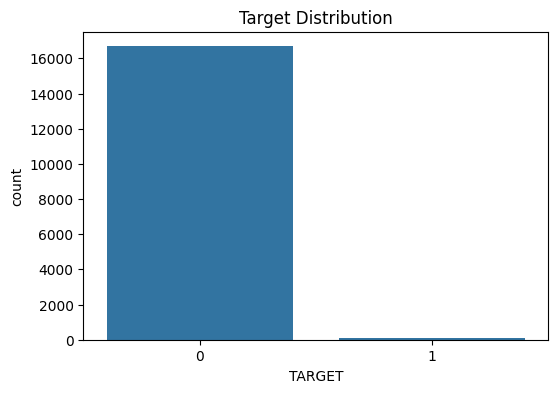

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='TARGET', data=df)
plt.title("Target Distribution")
plt.show()

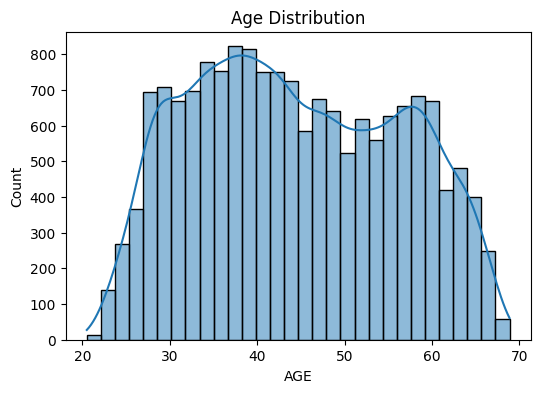

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['AGE'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

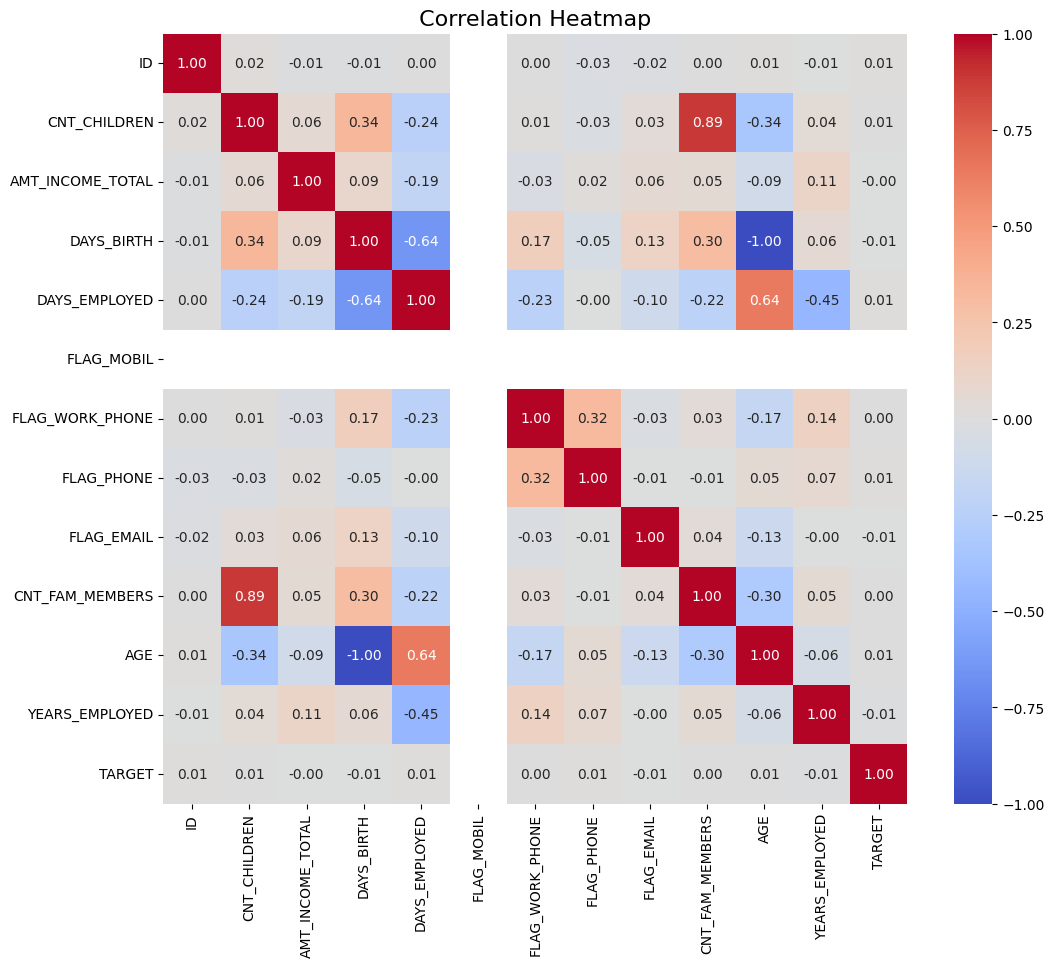

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title(" Correlation Heatmap ", fontsize=16)
plt.show()

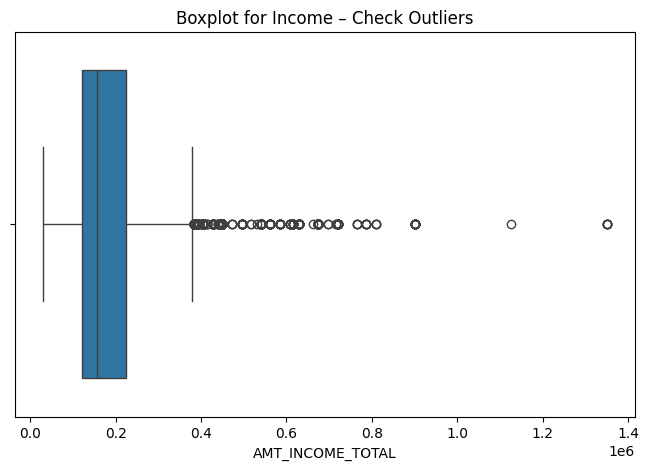

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df['AMT_INCOME_TOTAL'])
plt.title("Boxplot for Income – Check Outliers")
plt.show()

### Checking & Handling outliers

In [ ]:
import numpy as np

numeric_cols = ['AMT_INCOME_TOTAL',
                'CNT_FAM_MEMBERS',
                'CNT_CHILDREN',\
                'AGE',
                'YEARS_EMPLOYED']

for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

In [ ]:
df['AMT_INCOME_LOG'] = np.log1p(df['AMT_INCOME_TOTAL'])


In [ ]:
print(df.columns.tolist())

['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'AGE', 'YEARS_EMPLOYED', 'TARGET', 'AMT_INCOME_LOG']


In [ ]:
df.drop(columns=['ID','DAYS_BIRTH','DAYS_EMPLOYED'], inplace=True)

In [ ]:
features = ['AGE', 'YEARS_EMPLOYED', 'AMT_INCOME_TOTAL', 'CNT_CHILDREN',
            'CNT_FAM_MEMBERS', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
            'OCCUPATION_TYPE']


## Modeling

In [ ]:
X = df[features]
y = df['TARGET']

#### Encode Binary columnms

In [ ]:
binary_cols = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
for col in binary_cols:
    X[col] = X[col].map({'M':1, 'F':0, 'Y':1, 'N':0})

/tmp/ipykernel_646/138970395.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].map({'M':1, 'F':0, 'Y':1, 'N':0})
/tmp/ipykernel_646/138970395.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].map({'M':1, 'F':0, 'Y':1, 'N':0})
/tmp/ipykernel_646/138970395.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

#### Null handling

In [ ]:
num_cols = ['AGE', 'YEARS_EMPLOYED', 'AMT_INCOME_TOTAL', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS']
X[num_cols] = X[num_cols].fillna(X[num_cols].median())


/tmp/ipykernel_646/1432372501.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[num_cols] = X[num_cols].fillna(X[num_cols].median())


#### DAta splitting

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
ohe_cols = ['OCCUPATION_TYPE']
existing_ohe_cols = [col for col in ohe_cols if col in X_train.columns]

if existing_ohe_cols:
    X_train = pd.get_dummies(X_train, columns=existing_ohe_cols, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=existing_ohe_cols, drop_first=True)

    for col in X_train.columns:
        if col not in X_test.columns:
            X_test[col] = 0
    X_test = X_test[X_train.columns]

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
"""
from imblearn.over_sampling import SMOTE
sm = SMOTE(sampling_strategy=0.5, random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)
"""
from imblearn.over_sampling import SMOTE

sm = SMOTE(sampling_strategy=0.7, random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

In [ ]:
print("After SMOTE:")
print(y_train_res.value_counts())
print(y_train_res.value_counts(normalize=True))

After SMOTE:
TARGET
0    13344
1     9340
Name: count, dtype: int64
TARGET
0    0.588256
1    0.411744
Name: proportion, dtype: float64


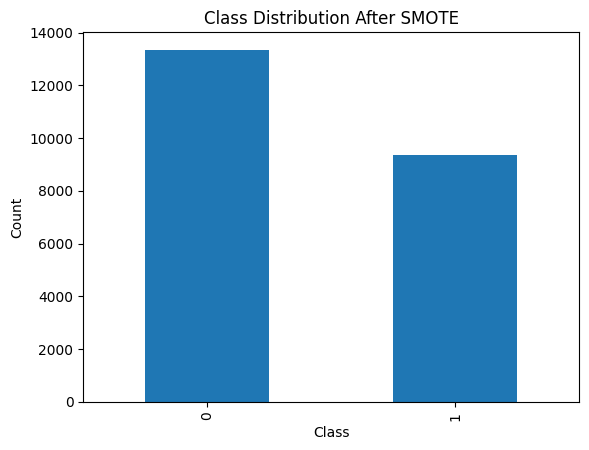

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
y_train_res.value_counts().plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])
scale_pos_weight = ratio * 0.7
print(scale_pos_weight )

111.2


By Using XGB

In [ ]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    scale_pos_weight=ratio,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_proba = xgb_model.predict_proba(X_test)[:,1]
y_pred = (y_proba > 0.7).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9785586658725431
Confusion Matrix:
 [[3284   53]
 [  19    2]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      3337
           1       0.04      0.10      0.05        21

    accuracy                           0.98      3358
   macro avg       0.52      0.54      0.52      3358
weighted avg       0.99      0.98      0.98      3358



By Using SVM

In [ ]:

from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model.fit(X_train_res, y_train_res)

y_scores = svm_model.decision_function(X_test_scaled)
y_pred_new = (y_scores > -0.2).astype(int)

In [ ]:
y_train_pred = svm_model.predict(X_train_res)
y_test_pred = svm_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Training Accuracy:", accuracy_score(y_train_res, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

Training Accuracy: 0.9068947275612766
Testing Accuracy: 0.8454437164979154

Confusion Matrix:
 [[2836  501]
 [  18    3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.85      0.92      3337
           1       0.01      0.14      0.01        21

    accuracy                           0.85      3358
   macro avg       0.50      0.50      0.46      3358
weighted avg       0.99      0.85      0.91      3358

